In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 

import pandas as pd
import torch.nn as nn
import torch.optim as optim

import xarray as xr

import torch.nn as nn
import torch.optim as optim
import torch

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


import seaborn as sns

# Load and preprocess data
We want to determine whether there is snow or not at the Folgefonna skisenter based on other variables

In [9]:
df = pd.read_csv('../data/folgefonna-skisenter_vaeret.csv', index_col=0)
df_example = df.sample(50)
df_example['Snow_presence'] = 1*(df_example.Snowdepth>0)
X = df_example[['Tmin']]
y = df_example['Snow_presence']

<Axes: ylabel='Frequency'>

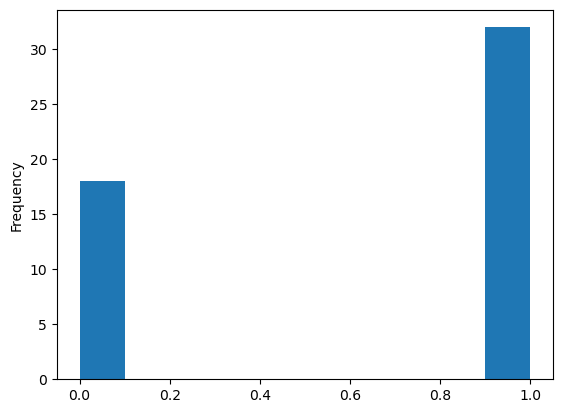

In [10]:
y.plot.hist()

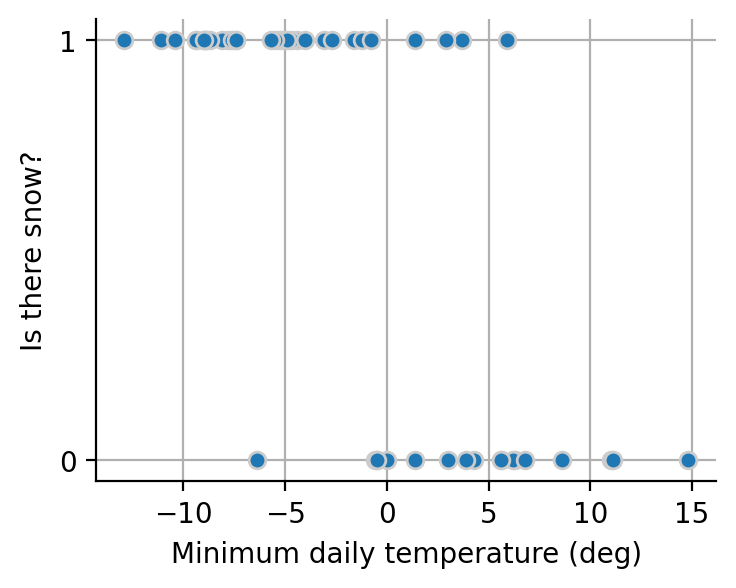

In [22]:
fig, ax = plt.subplots(figsize = (4,3), dpi=200)
plt.scatter(df_example.Tmin, df_example.Snow_presence, zorder=10, edgecolor='.8')
sns.despine()
ax.set_yticks([0,1])
ax.set_ylabel('Is there snow?')
ax.set_xlabel('Minimum daily temperature (deg)')
ax.grid(zorder=0)

In [24]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf = clf.fit(X, y)

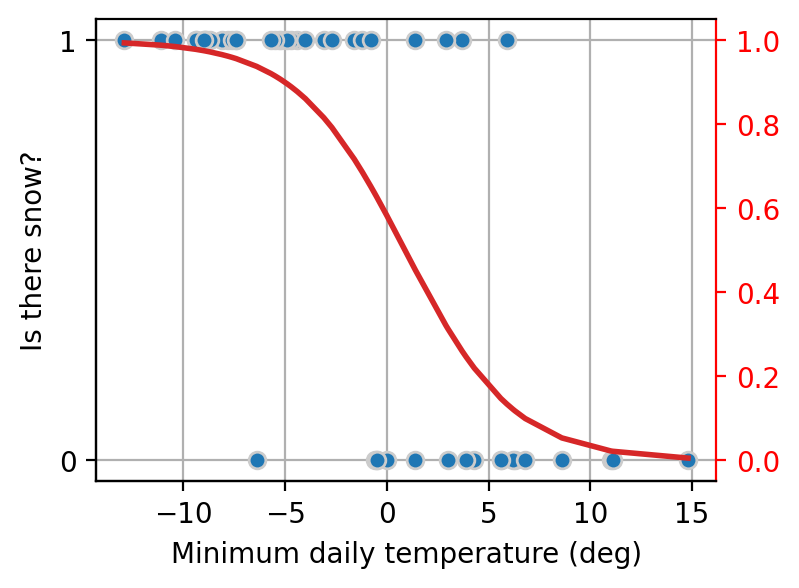

In [36]:
fig, ax = plt.subplots(figsize = (4,3), dpi=200)
plt.scatter(df_example.Tmin, df_example.Snow_presence, zorder=10, edgecolor='.8')
sns.despine()
ax.set_yticks([0,1])
ax.set_ylabel('Is there snow?')
ax.set_xlabel('Minimum daily temperature (deg)')
ax.grid(zorder=0)
ax2 = ax.twinx()
plt.plot(X.sort_values('Tmin'),clf.predict_proba(X.sort_values('Tmin'))[:,1], lw=2, color='C3', label='Logistic Regression model', zorder=100)
ax2.set_ylim(ax.get_ylim())
ax2.spines['right'].set_color('red')
ax2.tick_params(color='red', labelcolor='red')


# Split train and test
We split the data into two parts 

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,shuffle=True)

# Define model

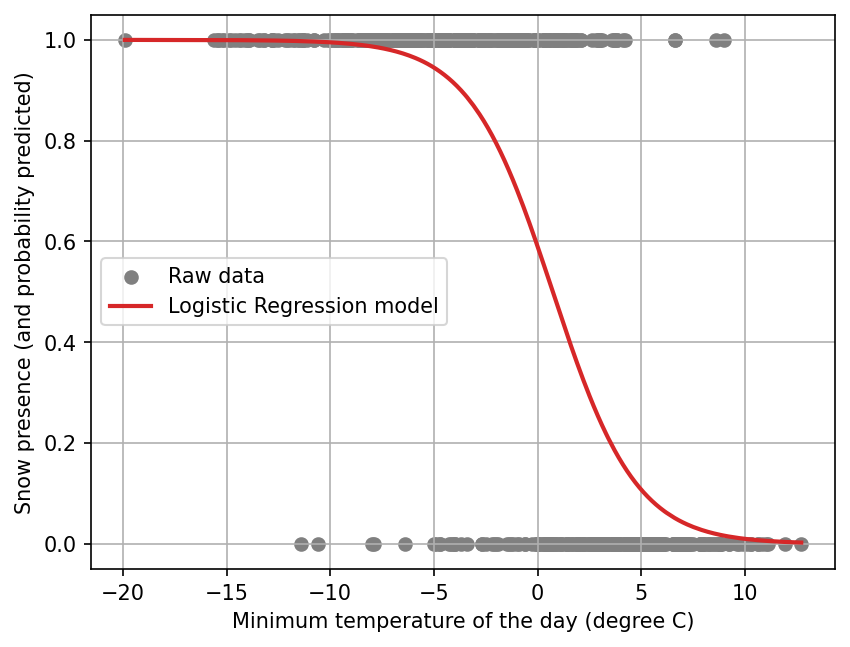

In [88]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf = clf.fit(X_train, y_train)

fig, ax = plt.subplots(dpi=150)
plt.scatter(X_test,y_test, color='.5', label='Raw data')
plt.plot(X_test.sort_values('Tmin'),clf.predict_proba(X_test.sort_values('Tmin'))[:,1], lw=2, color='C3', label='Logistic Regression model')
plt.grid()
ax.set_xlabel('Minimum temperature of the day (degree C)')
ax.set_ylabel('Snow presence (and probability predicted)')
ax.legend()


# Evaluate the model on test data

[Text(0.5, 0, 'No Snow'), Text(1.5, 0, 'Snow')]

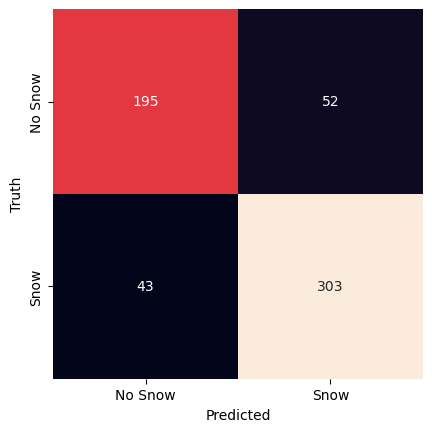

In [89]:
matrix = confusion_matrix(y_test, clf.predict(X_test))
matrix
fig, ax = plt.subplots()
sns.heatmap(matrix, square=True, cbar=False, annot=True, fmt='.0f',ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Truth')
ax.set_yticklabels(['No Snow','Snow'])
ax.set_xticklabels(['No Snow','Snow'])